In [2]:
import argparse
import cv2
import numpy as np
import torch


from backbones import get_model
from expression import *
from expression.datasets import RAFDBDataset
from utils.utils_config import get_config
from expression.models import SwinTransFER
from torchvision.transforms import Compose, Normalize, ToTensor

total_predicts = []
total_logits = []
swin = get_model('swin_t')
net = SwinTransFER(swin=swin, swin_num_features=768, num_classes=7, cam=True)

dict_checkpoint = torch.load('results/checkpoint_step_59999_gpu_0.pt')
net.load_state_dict(dict_checkpoint["state_dict_model"])


dataset_val = RAFDBDataset(choose="test",
                           data_path="dataset/RAF",
                         label_path="dataset/list_patition_label.txt",
                         img_size=112)
test_loader = torch.utils.data.DataLoader(dataset_val, batch_size=128,
                shuffle=False, num_workers=2, pin_memory=True, drop_last=False)


with torch.no_grad():
    net.cuda()
    net.eval()
    
    bingo_cnt = 0
    sample_cnt = 0
    for idx, (images, target, _) in enumerate(test_loader):
        img = images.cuda(non_blocking=True)
        target = target.cuda(non_blocking=True)

        outputs, _ = net(img)

        _, predicts = torch.max(outputs, 1)
        total_predicts.append(predicts.cpu().numpy())
        total_logits.append(outputs.cpu().numpy())
        
        correct_num = torch.eq(predicts, target)
        bingo_cnt += correct_num.sum().cpu()
        sample_cnt += outputs.size(0)
        
    acc = bingo_cnt.float() / float(sample_cnt)
    acc = np.around(acc.numpy(), 4)
    print("Validation accuracy:%.4f. " % (acc))

/media/brolyn-ntg/Windows-SSD/MyData/User/General-Data/Code/data_analyst/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/brolyn-ntg/Windows-SSD/MyData/User/General-Data/Code/data_analyst/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/media/brolyn-ntg/Windows-SSD/MyData/User/General-Data/Code/data_analyst/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # typ

Validation accuracy:0.9270. 


In [3]:
new_total_predicts = np.concatenate(total_predicts)
total_labels = np.array(test_loader.dataset.labels)

mean_acc = 0
for j in range(7):
    class_num = j
    class_idx = []
    for i in range(len(total_labels)):
        if total_labels[i] == class_num:
            class_idx.append(i)
    tempt = (new_total_predicts[np.array(class_idx)] == total_labels[np.array(class_idx)]).sum() / len(class_idx)
    mean_acc += tempt
    print(f"Class {class_num} accuracy: {tempt:.4f}")
print(f"Macro class accuracy: {mean_acc/7:.4f}")

Class 0 accuracy: 0.9271
Class 1 accuracy: 0.7432
Class 2 accuracy: 0.8562
Class 3 accuracy: 0.9688
Class 4 accuracy: 0.8996
Class 5 accuracy: 0.8642
Class 6 accuracy: 0.9250
Macro class accuracy: 0.8834


In [6]:
# Tính toán các độ đo chi tiết theo công thức từ confusion matrix
num_classes = 7
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for true_label, pred_label in zip(total_labels, new_total_predicts):
    cm[true_label, pred_label] += 1

true_positives = np.diag(cm).astype(np.float64)
false_positives = np.sum(cm, axis=0).astype(np.float64) - true_positives
false_negatives = np.sum(cm, axis=1).astype(np.float64) - true_positives
true_negatives = np.sum(cm).astype(np.float64) - (true_positives + false_positives + false_negatives)

# Với multiclass, overall accuracy là số dự đoán đúng trên tổng số mẫu
accuracy = np.trace(cm) / np.sum(cm)
precision = np.divide(true_positives, true_positives + false_positives, out=np.zeros_like(true_positives), where=(true_positives + false_positives) != 0)
recall = np.divide(true_positives, true_positives + false_negatives, out=np.zeros_like(true_positives), where=(true_positives + false_negatives) != 0)
f1_score = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) != 0)

print("Detailed metrics from confusion matrix formulas:")
print(f"Overall accuracy: {accuracy:.4f}")
for class_idx in range(num_classes):
    print(f"Class {class_idx}: Precision={precision[class_idx]:.4f}, Recall={recall[class_idx]:.4f}, F1={f1_score[class_idx]:.4f}")
print(f"Macro Precision: {np.mean(precision):.4f}")
print(f"Macro Recall: {np.mean(recall):.4f}")
print(f"Macro F1: {np.mean(f1_score):.4f}")
print(f"Weighted F1: {np.sum(f1_score * np.sum(cm, axis=1)) / np.sum(cm):.4f}")

Detailed metrics from confusion matrix formulas:
Overall accuracy: 0.9270
Class 0: Precision=0.9242, Recall=0.9271, F1=0.9256
Class 1: Precision=0.6875, Recall=0.7432, F1=0.7143
Class 2: Precision=0.7784, Recall=0.8562, F1=0.8155
Class 3: Precision=0.9745, Recall=0.9688, F1=0.9716
Class 4: Precision=0.9130, Recall=0.8996, F1=0.9062
Class 5: Precision=0.9333, Recall=0.8642, F1=0.8974
Class 6: Precision=0.9209, Recall=0.9250, F1=0.9230
Macro Precision: 0.8760
Macro Recall: 0.8834
Macro F1: 0.8791
Weighted F1: 0.9275


# Các độ đo đánh giá mô hình

## 1. Accuracy (Độ chính xác)
- **Định nghĩa**: Tỷ lệ số dự đoán đúng trên tổng số mẫu.
- **Công thức**: Accuracy = (TP + TN) / (TP + TN + FP + FN)
- **Ý nghĩa**: Đo lường tổng thể mô hình dự đoán đúng bao nhiêu.

## 2. Precision (Độ chính xác dương)
- **Định nghĩa**: Tỷ lệ số dự đoán dương đúng trên tổng số dự đoán dương.
- **Công thức**: Precision = TP / (TP + FP)
- **Ý nghĩa**: Trong các mẫu được dự đoán là dương, bao nhiêu thực sự dương.

## 3. Recall (Độ nhạy)
- **Định nghĩa**: Tỷ lệ số dự đoán dương đúng trên tổng số mẫu dương thực tế.
- **Công thức**: Recall = TP / (TP + FN)
- **Ý nghĩa**: Trong các mẫu dương thực tế, mô hình phát hiện được bao nhiêu.

## 4. F1-Score
- **Định nghĩa**: Trung bình điều hòa của Precision và Recall.
- **Công thức**: F1 = 2 * (Precision * Recall) / (Precision + Recall)
- **Ý nghĩa**: Cân bằng giữa Precision và Recall, hữu ích khi dữ liệu không cân bằng.

**Lưu ý**: TP (True Positive), TN (True Negative), FP (False Positive), FN (False Negative).

## Confusion Matrix
Ma trận nhầm lẫn hiển thị số lượng dự đoán đúng và sai cho từng lớp.

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.92      0.93      0.93       329
     Class 1       0.69      0.74      0.71        74
     Class 2       0.78      0.86      0.82       160
     Class 3       0.97      0.97      0.97      1185
     Class 4       0.91      0.90      0.91       478
     Class 5       0.93      0.86      0.90       162
     Class 6       0.92      0.93      0.92       680

    accuracy                           0.93      3068
   macro avg       0.88      0.88      0.88      3068
weighted avg       0.93      0.93      0.93      3068



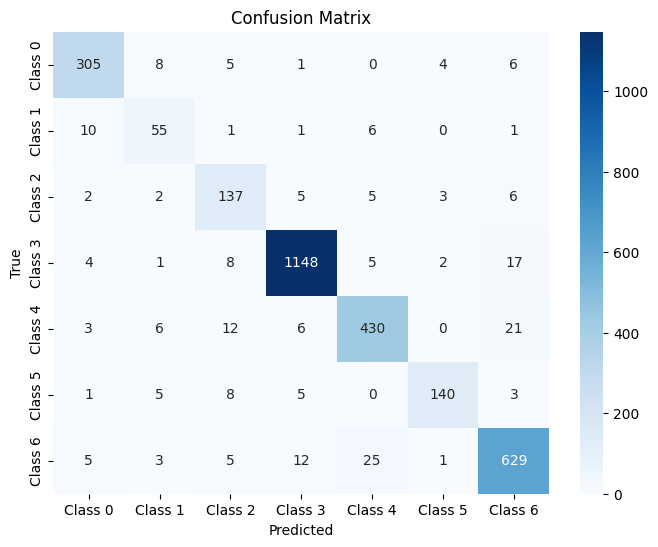

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán các độ đo
print("Classification Report:")
print(classification_report(total_labels, new_total_predicts, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6']))

# Vẽ Confusion Matrix
cm = confusion_matrix(total_labels, new_total_predicts)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6'], yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5', 'Class 6'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()